# 🚇 Predicción de Demanda de Metro de Madrid con LSTM

## Contexto del problema

Predecir el número de viajeros diarios del metro de Madrid es un problema de **forecasting de series temporales**. Conocer la demanda futura permite:
- Optimizar la frecuencia de trenes en horas punta
- Planificar mantenimiento en momentos de baja demanda
- Asignar recursos humanos (conductores, personal de seguridad)

## ¿Por qué LSTM para series temporales?

A diferencia de los modelos estadísticos clásicos (ARIMA, SARIMA), las LSTM pueden:
- Capturar **patrones no lineales** (festivos, eventos especiales, huelgas)
- Aprender dependencias de **múltiples escalas temporales** simultáneamente (día de la semana + estación del año)
- Incorporar **variables exógenas** (temperatura, calendario laboral) de forma natural

> 📅 Los datos cubren de 2015 a 2024 — suficiente para capturar la estacionalidad anual, el patrón semanal y eventos extraordinarios como la pandemia de 2020.

### ⏹️ Early Stopping: detener el entrenamiento en el momento óptimo

Sin Early Stopping, el modelo podría sobreentrenarse: las métricas de training siguen mejorando pero las de validación empeoran (overfitting).

**Parámetros clave:**
- `monitor='val_loss'`: observamos la pérdida en el conjunto de validación
- `patience=20`: esperamos 20 épocas sin mejora antes de parar
- `restore_best_weights=True`: al terminar, recuperamos los pesos de la época con menor val_loss

> 💡 Esto nos permite poner `epochs=200` sin preocuparnos de sobreentrenar: el modelo parará automáticamente en el momento óptimo.

In [1]:
# import packages
import math

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import Sequence
from datetime import timedelta
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from keras.callbacks import EarlyStopping

import numpy as np
import pandas as pd
import time

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


In [2]:

# read the dataset into python
df = pd.read_csv('data\Demanda_Diaria_Metro_2015_2024.csv', delimiter=',')
df.head()

<>:2: SyntaxWarning: invalid escape sequence '\D'
<>:2: SyntaxWarning: invalid escape sequence '\D'
C:\Users\tomas\AppData\Local\Temp\ipykernel_84344\2434192227.py:2: SyntaxWarning: invalid escape sequence '\D'
  df = pd.read_csv('data\Demanda_Diaria_Metro_2015_2024.csv', delimiter=',')


,Fecha,Demanda
0,2015-01-01,551814
1,2015-01-02,1538946
2,2015-01-03,1150162
3,2015-01-04,930805
4,2015-01-05,1651540


### 📋 Descripción del dataset

El dataset contiene la **demanda diaria agregada** del Metro de Madrid: el número total de validaciones en todas las estaciones en cada día.

**Variables:**
- `Fecha`: fecha del registro
- `Demanda`: número de viajeros ese día

**Patrones esperados:**
- 📅 Patrón semanal: mucho menos tráfico los domingos y festivos
- 🌞 Patrón estacional: verano con menos demanda (vacaciones, agosto)
- 📉 Anomalía 2020: caída drástica por COVID-19

Son datos diarios

In [3]:
dtypes = df.dtypes
dtypes


Fecha        str
Demanda    int64
dtype: object

In [4]:
df['Fecha'] = pd.to_datetime(df['Fecha'])
df

,Fecha,Demanda
0,2015-01-01,551814
1,2015-01-02,1538946
2,2015-01-03,1150162
3,2015-01-04,930805
4,2015-01-05,1651540
...,...,...
3586,2024-11-26,2486822
3587,2024-11-27,2541525
3588,2024-11-28,2724600
3589,2024-11-29,2783341


In [5]:
dtypes = df.dtypes
dtypes

Fecha      datetime64[us]
Demanda             int64
dtype: object

In [6]:
df.shape

(3591, 2)

In [7]:
 # Hay nulos??
print(df.isnull().sum())

Fecha      0
Demanda    0
dtype: int64


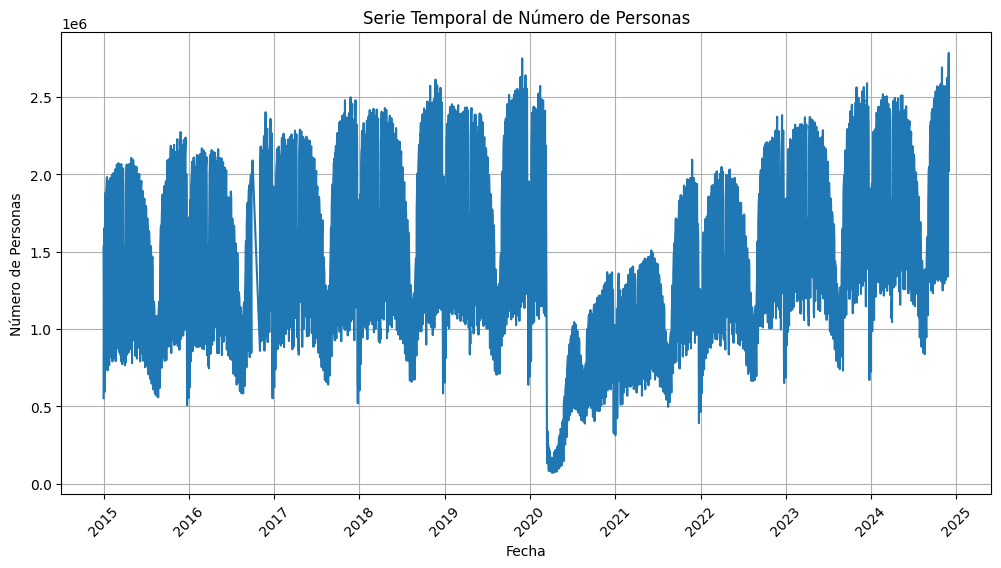

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Supongamos que tienes un DataFrame llamado 'df' con las columnas 'fecha' y 'num_personas'
df['Fecha'] = pd.to_datetime(df['Fecha'])  # Asegurarse de que la columna de fechas esté en formato datetime
df = df.sort_values(by='Fecha')  # Ordenar por fecha si no está ordenado

# Crear el gráfico
plt.figure(figsize=(12, 6))
plt.plot(df['Fecha'], df['Demanda'],  linestyle='-')

# Personalización del gráfico
plt.xlabel('Fecha')
plt.ylabel('Número de Personas')
plt.title('Serie Temporal de Número de Personas')
plt.xticks(rotation=45)  # Rotar etiquetas del eje X para mejor visualización
plt.grid(True)

# Mostrar el gráfico
plt.show()

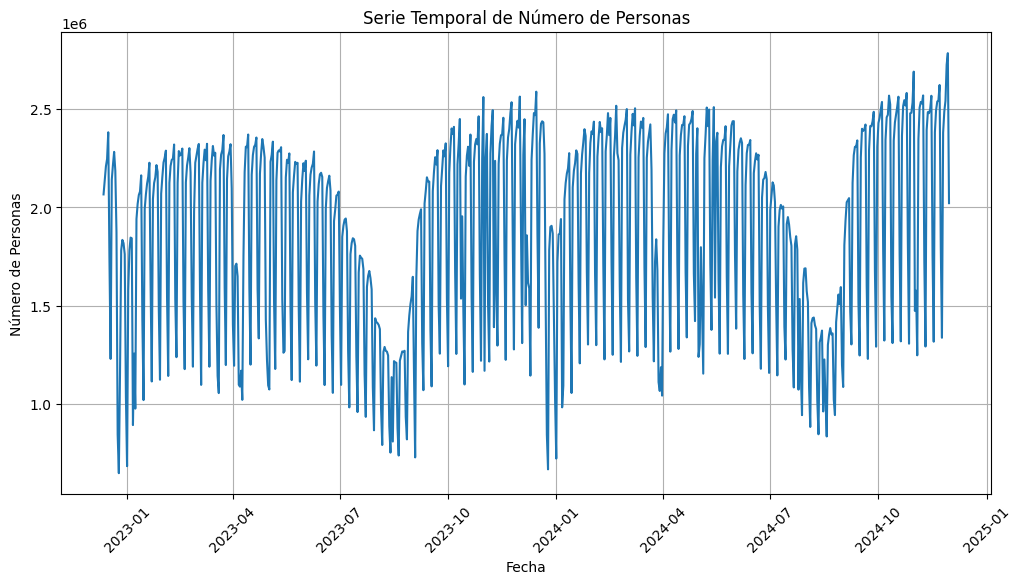

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Supongamos que tienes un DataFrame llamado 'df' con las columnas 'fecha' y 'num_personas'
df['Fecha'] = pd.to_datetime(df['Fecha'])  # Asegurarse de que la columna de fechas esté en formato datetime
df = df.sort_values(by='Fecha')  # Ordenar por fecha si no está ordenado

# Crear el gráfico
plt.figure(figsize=(12, 6))
plt.plot(df['Fecha'].iloc[-720:], df['Demanda'].iloc[-720:],  linestyle='-')

# Personalización del gráfico
plt.xlabel('Fecha')
plt.ylabel('Número de Personas')
plt.title('Serie Temporal de Número de Personas')
plt.xticks(rotation=45)  # Rotar etiquetas del eje X para mejor visualización
plt.grid(True)

# Mostrar el gráfico
plt.show()

Definimos 2 conjuntos: test y train

---
## ✂️ División temporal train / test

En series temporales, la división debe ser **temporal** — no aleatoria. Usar datos futuros para entrenar el modelo sería **data leakage**.

La convención estándar es usar los últimos N días como test (aquí ~84 días ≈ 3 meses) y todo lo anterior como entrenamiento.

In [10]:
# División temporal correcta: train = primeros N-84 días, test = últimos 84 días
training_set = df.iloc[:-84, 1:2].values
test_set     = df.iloc[-84:, 1:2].values

In [11]:
test_set.shape

(84, 1)

In [12]:
training_set.shape

(3507, 1)

In [13]:
training_set.shape[0]

3507

El objetivo e predecir la demanda diaria de viajeros en el metro de madrid
Nos creamos una matriz de datos donde la variable objetivo es la demanada y las variables input son las 30 observaciones escalado con MinMax

In [14]:
# Feature Scaling
sc = MinMaxScaler(feature_range = (0, 1))
training_set_scaled = sc.fit_transform(training_set)
# Creating a data structure with 60 time-steps and 1 output
X_train = []
y_train = []
for i in range(60, training_set.shape[0]):
    X_train.append(training_set_scaled[i-60:i, 0])
    y_train.append(training_set_scaled[i, 0])
X_train, y_train = np.array(X_train), np.array(y_train)
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
#(740, 60, 1)

### 🔢 Normalización: MinMaxScaler

La LSTM es sensible a la escala de los datos. MinMaxScaler transforma la demanda al rango **[0, 1]**:

$$x_{norm} = \frac{x - x_{min}}{x_{max} - x_{min}}$$

> ⚠️ **Punto crítico**: el scaler debe ajustarse **solo con datos de training** (`fit_transform`) y aplicarse a test sin reajustar (`transform`). Si usas los datos de test para calcular el min/max, introduces información futura en el modelo.

Al final, para evaluar en la escala original, se aplica `inverse_transform`.

In [15]:
# 1. Dividir la serie temporal en entrenamiento y validación
split_index = int(len(training_set) * 0.8)
train_data = training_set[:split_index]
val_data = training_set[split_index:]

# 2. Escalar por separado
sc = MinMaxScaler(feature_range=(0, 1))
train_scaled = sc.fit_transform(train_data)
val_scaled = sc.transform(val_data)  # ¡Importante! Usamos el mismo scaler

# 3. Crear ventanas para entrenamiento
X_train, y_train = [], []
for i in range(60, len(train_scaled)):
    X_train.append(train_scaled[i-60:i, 0])
    y_train.append(train_scaled[i, 0])
X_train, y_train = np.array(X_train), np.array(y_train)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))

# 4. Crear ventanas para validación
X_val, y_val = [], []
for i in range(60, len(val_scaled)):
    X_val.append(val_scaled[i-60:i, 0])
    y_val.append(val_scaled[i, 0])
X_val, y_val = np.array(X_val), np.array(y_val)
X_val = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))


In [16]:
X_train.shape

(2745, 60, 1)

In [17]:
model = Sequential()
    # Add an LSTM layer to process sequences of words
model.add(LSTM(50))
    # Add a dense layer with sigmoid activation for binary classification (0 or 1)
#model.add(Dense(1, activation='sigmoid'))
model.add(Dense(units = 1))
    # Compile the model with loss function, optimizer, and metrics
model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mse', 'mae', 'mape']  # Puedes añadir más métricas para análisis
)


### ⏹️ Early Stopping: detener el entrenamiento en el momento óptimo

Sin Early Stopping, el modelo podría sobreentrenarse: las métricas de training siguen mejorando pero las de validación empeoran (overfitting).

**Parámetros clave:**
- `monitor='val_loss'`: observamos la pérdida en el conjunto de validación
- `patience=20`: esperamos 20 épocas sin mejora antes de parar
- `restore_best_weights=True`: al terminar, recuperamos los pesos de la época con menor val_loss

> 💡 Esto nos permite poner `epochs=200` sin preocuparnos de sobreentrenar: el modelo parará automáticamente en el momento óptimo.

In [18]:
from tensorflow.keras.callbacks import EarlyStopping

# Crear el callback
early_stop = EarlyStopping(
    monitor='val_loss',     # Métrica que se observa
    patience=20,            # Nº de épocas sin mejora antes de parar
    restore_best_weights=True # Recupera los mejores pesos
)

# Entrenar el modelo con validación
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),  # Necesitas un conjunto de validación
    epochs=100,
    batch_size=32,
    callbacks=[early_stop]
)


Epoch 1/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0500 - mae: 0.1798 - mape: 57435.2969 - mse: 0.0500 - val_loss: 0.0295 - val_mae: 0.1575 - val_mape: 26.8800 - val_mse: 0.0295
Epoch 2/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0297 - mae: 0.1488 - mape: 49178.0195 - mse: 0.0297 - val_loss: 0.0278 - val_mae: 0.1505 - val_mape: 26.6751 - val_mse: 0.0278
Epoch 3/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0293 - mae: 0.1475 - mape: 32868.3203 - mse: 0.0293 - val_loss: 0.0271 - val_mae: 0.1437 - val_mape: 26.4622 - val_mse: 0.0271
Epoch 4/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0283 - mae: 0.1445 - mape: 33308.6758 - mse: 0.0283 - val_loss: 0.0270 - val_mae: 0.1363 - val_mape: 26.2135 - val_mse: 0.0270
Epoch 5/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0280 - mae: 0.1423 - mape: 24932.0391 - mse: 0.0280 - val_loss: 0.0254 - val_mae: 0.1393 - val_mape: 25.5099 - val_mse: 0.0254
Epoch 6/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 

In [19]:

# Fitting the RNN to the Training set
#model.fit(X_train, y_train, epochs = 100, batch_size = 32)

In [19]:
test_set.shape[0]

84

In [20]:
# Construcción correcta de X_test
# Necesitamos los 60 días anteriores al periodo test para construir la primera ventana.
# Los concatenamos desde el dataset completo y escalamos con el mismo scaler (sin refitear).

dataset_total = df['Demanda'].values.reshape(-1, 1)
inputs = dataset_total[len(dataset_total) - len(test_set) - 60:]
test_set_scaled = sc.transform(inputs)  # sc ya fue fitteado solo con train — sin data leakage

X_test = []
for i in range(60, test_set_scaled.shape[0]):
    X_test.append(test_set_scaled[i-60:i, 0])
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
# Shape esperado: (84, 60, 1)

In [21]:
X_test.shape  # Esperado: (84, 60, 1)

(84, 60, 1)

In [22]:
X_test.shape

(84, 60, 1)

In [27]:
# El reshape ya se realizó en la celda anterior junto con la construcción de X_test

In [23]:
y_pred = model.predict(X_test)
y_pred

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


array([[0.42331395],
       [0.6930071 ],
       [0.7298242 ],
       [0.7830455 ],
       [0.7958468 ],
       [0.62974024],
       [0.4843464 ],
       [0.47123075],
       [0.6265084 ],
       [0.75246054],
       [0.80706537],
       [0.82626635],
       [0.71913284],
       [0.51186436],
       [0.44375587],
       [0.77819306],
       [0.77708185],
       [0.82021   ],
       [0.8487975 ],
       [0.8022399 ],
       [0.5540322 ],
       [0.42963633],
       [0.82377404],
       [0.79106945],
       [0.84049016],
       [0.8649894 ],
       [0.8534793 ],
       [0.5679165 ],
       [0.44448256],
       [0.83691275],
       [0.8129116 ],
       [0.8627148 ],
       [0.8738008 ],
       [0.890101  ],
       [0.56932575],
       [0.4356233 ],
       [0.8225091 ],
       [0.83309484],
       [0.858478  ],
       [0.87339735],
       [0.90528274],
       [0.56791794],
       [0.43784383],
       [0.8426073 ],
       [0.84541196],
       [0.88727814],
       [0.90099925],
       [0.894

In [24]:
y_pred = sc.inverse_transform(y_pred)
y_pred

array([[1.2031181e+06],
       [1.9253515e+06],
       [2.0239470e+06],
       [2.1664728e+06],
       [2.2007545e+06],
       [1.7559240e+06],
       [1.3665619e+06],
       [1.3314385e+06],
       [1.7472692e+06],
       [2.0845668e+06],
       [2.2307975e+06],
       [2.2822172e+06],
       [1.9953158e+06],
       [1.4402545e+06],
       [1.2578612e+06],
       [2.1534780e+06],
       [2.1505022e+06],
       [2.2659985e+06],
       [2.3425555e+06],
       [2.2178750e+06],
       [1.5531792e+06],
       [1.2200494e+06],
       [2.2755430e+06],
       [2.1879608e+06],
       [2.3203085e+06],
       [2.3859170e+06],
       [2.3550932e+06],
       [1.5903611e+06],
       [1.2598074e+06],
       [2.3107282e+06],
       [2.2464538e+06],
       [2.3798258e+06],
       [2.4095138e+06],
       [2.4531655e+06],
       [1.5941350e+06],
       [1.2360824e+06],
       [2.2721555e+06],
       [2.3005040e+06],
       [2.3684795e+06],
       [2.4084332e+06],
       [2.4938218e+06],
       [1.590365

retocar esto....

In [25]:
training_set

array([[ 551814],
       [1538946],
       [1150162],
       ...,
       [2037047],
       [2047048],
       [1470915]], shape=(3507, 1))

In [26]:
df['Fecha'].iloc[-84:].shape

(84,)

In [27]:
df['Fecha'].iloc[-84:].values

array(['2024-09-08T00:00:00.000000', '2024-09-09T00:00:00.000000',
       '2024-09-10T00:00:00.000000', '2024-09-11T00:00:00.000000',
       '2024-09-12T00:00:00.000000', '2024-09-13T00:00:00.000000',
       '2024-09-14T00:00:00.000000', '2024-09-15T00:00:00.000000',
       '2024-09-16T00:00:00.000000', '2024-09-17T00:00:00.000000',
       '2024-09-18T00:00:00.000000', '2024-09-19T00:00:00.000000',
       '2024-09-20T00:00:00.000000', '2024-09-21T00:00:00.000000',
       '2024-09-22T00:00:00.000000', '2024-09-23T00:00:00.000000',
       '2024-09-24T00:00:00.000000', '2024-09-25T00:00:00.000000',
       '2024-09-26T00:00:00.000000', '2024-09-27T00:00:00.000000',
       '2024-09-28T00:00:00.000000', '2024-09-29T00:00:00.000000',
       '2024-09-30T00:00:00.000000', '2024-10-01T00:00:00.000000',
       '2024-10-02T00:00:00.000000', '2024-10-03T00:00:00.000000',
       '2024-10-04T00:00:00.000000', '2024-10-05T00:00:00.000000',
       '2024-10-06T00:00:00.000000', '2024-10-07T00:00:00.0000

In [28]:
y_pred.shape

(84, 1)

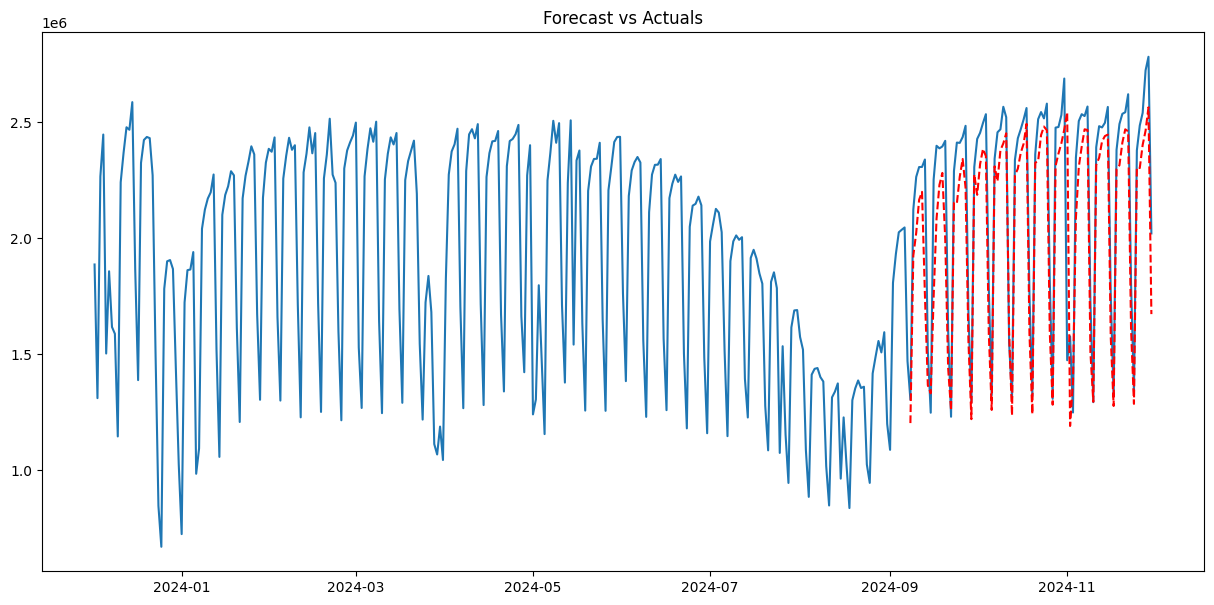

In [29]:
plt.figure(figsize=(15, 7))

plt.plot(df['Fecha'].iloc[-365:], df['Demanda'].iloc[-365:])
plt.plot(df['Fecha'].iloc[-84:], y_pred, color='red', linestyle='--')
#plt.plot(predictions_pmd, color='gray')
#plt.plot(test, color='blue')
plt.title('Forecast vs Actuals')
plt.show()

In [30]:
from statsmodels.tsa.stattools import acf
# Accuracy metrics
def forecast_accuracy(forecast, actual):
    mape = np.mean(np.abs(forecast - actual)/np.abs(actual))  # MAPE
    me = np.mean(forecast - actual)             # ME
    mae = np.mean(np.abs(forecast - actual))    # MAE
    mpe = np.mean((forecast - actual)/actual)   # MPE
    rmse = np.mean((forecast - actual)**2)**.5  # RMSE
    corr = np.corrcoef(forecast, actual)[0,1]   # corr
    mins = np.amin(np.hstack([forecast[:,None], 
                              actual[:,None]]), axis=1)
    maxs = np.amax(np.hstack([forecast[:,None], 
                              actual[:,None]]), axis=1)
    minmax = 1 - np.mean(mins/maxs)             # minmax
    acf1 = acf(forecast-actual)[1]                      # ACF1
    resultados={'mape':mape, 'me':me, 'mae': mae, 
            'mpe': mpe, 'rmse':rmse, 'acf1':acf1, 
            'corr':corr, 'minmax':minmax}
    pd.options.display.float_format = '{:.6f}'.format #esto es para que lo pinte en formato float
    df = pd.DataFrame(resultados.items(), columns=["Métrica", "Valor"])
    return(df)


In [31]:
 df['Demanda'].iloc[-24:].to_numpy()


array([2527541, 2568631, 1727221, 1293345, 2393150, 2484037, 2478468,
       2498651, 2566905, 1756434, 1317871, 2381845, 2493263, 2537142,
       2544040, 2621743, 1803141, 1337813, 2379559, 2486822, 2541525,
       2724600, 2783341, 2021444])

In [32]:
y_pred.T[0]

array([1.2031181e+06, 1.9253515e+06, 2.0239470e+06, 2.1664728e+06,
       2.2007545e+06, 1.7559240e+06, 1.3665619e+06, 1.3314385e+06,
       1.7472692e+06, 2.0845668e+06, 2.2307975e+06, 2.2822172e+06,
       1.9953158e+06, 1.4402545e+06, 1.2578612e+06, 2.1534780e+06,
       2.1505022e+06, 2.2659985e+06, 2.3425555e+06, 2.2178750e+06,
       1.5531792e+06, 1.2200494e+06, 2.2755430e+06, 2.1879608e+06,
       2.3203085e+06, 2.3859170e+06, 2.3550932e+06, 1.5903611e+06,
       1.2598074e+06, 2.3107282e+06, 2.2464538e+06, 2.3798258e+06,
       2.4095138e+06, 2.4531655e+06, 1.5941350e+06, 1.2360824e+06,
       2.2721555e+06, 2.3005040e+06, 2.3684795e+06, 2.4084332e+06,
       2.4938218e+06, 1.5903650e+06, 1.2420289e+06, 2.3259782e+06,
       2.3334890e+06, 2.4456058e+06, 2.4823508e+06, 2.4661732e+06,
       1.5961904e+06, 1.2824072e+06, 2.3123268e+06, 2.3657705e+06,
       2.4104255e+06, 2.4700955e+06, 2.5436372e+06, 1.1905582e+06,
       1.3829035e+06, 2.0864565e+06, 2.3080332e+06, 2.3955622e

In [33]:
forecast_accuracy(y_pred.T[0], df['Demanda'].iloc[-84:].to_numpy())

,Métrica,Valor
0,mape,0.077002
1,me,-127588.927083
2,mae,159999.941964
3,mpe,-0.054324
4,rmse,214681.216302
5,acf1,-0.199706
6,corr,0.928937
7,minmax,0.073181


#### Añadimos capas a la RNN para ver si logramos mejorar el MAPE

---
## 🏗️ Arquitectura: LSTM apiladas (Stacked LSTM)

Apilar varias capas LSTM permite aprender **representaciones jerárquicas** del tiempo:
- Las capas inferiores aprenden patrones de corto alcance (día a día)
- Las capas superiores aprenden patrones de largo alcance (semana a semana, estacionalidad)

**`return_sequences=True`**: cuando apilamos LSTMs, las capas intermedias deben devolver la secuencia completa (no solo el último estado) para que la capa siguiente la procese.

**`Dropout(0.2)`**: entre capas LSTM reduce el overfitting desactivando aleatoriamente el 20% de las neuronas durante el entrenamiento.

In [35]:
model = Sequential()

# 1ª LSTM → devuelve secuencia para la siguiente
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))

# 2ª LSTM → devuelve secuencia para la siguiente
model.add(LSTM(units=50, return_sequences=True))
model.add(Dropout(0.2))

# 3ª LSTM → devuelve secuencia para la siguiente
model.add(LSTM(units=50, return_sequences=True))
model.add(Dropout(0.2))

# 4ª LSTM → última, NO devuelve secuencia (solo el último estado)
model.add(LSTM(units=50))
model.add(Dropout(0.2))

# Capa de salida
model.add(Dense(units=1))

model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mse', 'mae', 'mape']
)

### ⏹️ Early Stopping: detener el entrenamiento en el momento óptimo

Sin Early Stopping, el modelo podría sobreentrenarse: las métricas de training siguen mejorando pero las de validación empeoran (overfitting).

**Parámetros clave:**
- `monitor='val_loss'`: observamos la pérdida en el conjunto de validación
- `patience=20`: esperamos 20 épocas sin mejora antes de parar
- `restore_best_weights=True`: al terminar, recuperamos los pesos de la época con menor val_loss

> 💡 Esto nos permite poner `epochs=200` sin preocuparnos de sobreentrenar: el modelo parará automáticamente en el momento óptimo.

In [36]:
from tensorflow.keras.callbacks import EarlyStopping

# Crear el callback
early_stop = EarlyStopping(
    monitor='val_loss',     # Métrica que se observa
    patience=20,            # Nº de épocas sin mejora antes de parar
    restore_best_weights=True # Recupera los mejores pesos
)

# Entrenar el modelo con validación
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),  # Necesitas un conjunto de validación
    epochs=100,
    batch_size=32,
    callbacks=[early_stop]
)


Epoch 1/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - loss: 0.0454 - mae: 0.1710 - mape: 48499.8906 - mse: 0.0454 - val_loss: 0.0290 - val_mae: 0.1477 - val_mape: 26.8993 - val_mse: 0.0290
Epoch 2/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - loss: 0.0338 - mae: 0.1521 - mape: 56905.9844 - mse: 0.0338 - val_loss: 0.0302 - val_mae: 0.1545 - val_mape: 26.5799 - val_mse: 0.0302
Epoch 3/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - loss: 0.0350 - mae: 0.1562 - mape: 41835.3555 - mse: 0.0350 - val_loss: 0.0286 - val_mae: 0.1441 - val_mape: 26.7488 - val_mse: 0.0286
Epoch 4/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - loss: 0.0339 - mae: 0.1522 - mape: 35996.0859 - mse: 0.0339 - val_loss: 0.0405 - val_mae: 0.1792 - val_mape: 27.6558 - val_mse: 0.0405
Epoch 5/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - loss: 0.0335 - mae: 0.1514 - mape: 37648.8047 - mse: 0.0335 - val_loss: 0.0293 - val_mae: 0.1518 - val_mape: 26.4892 - val_mse: 0.0293
Epoch 6/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - l

In [37]:

y_pred2 = model.predict(X_test)
y_pred2 = sc.inverse_transform(y_pred2)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step


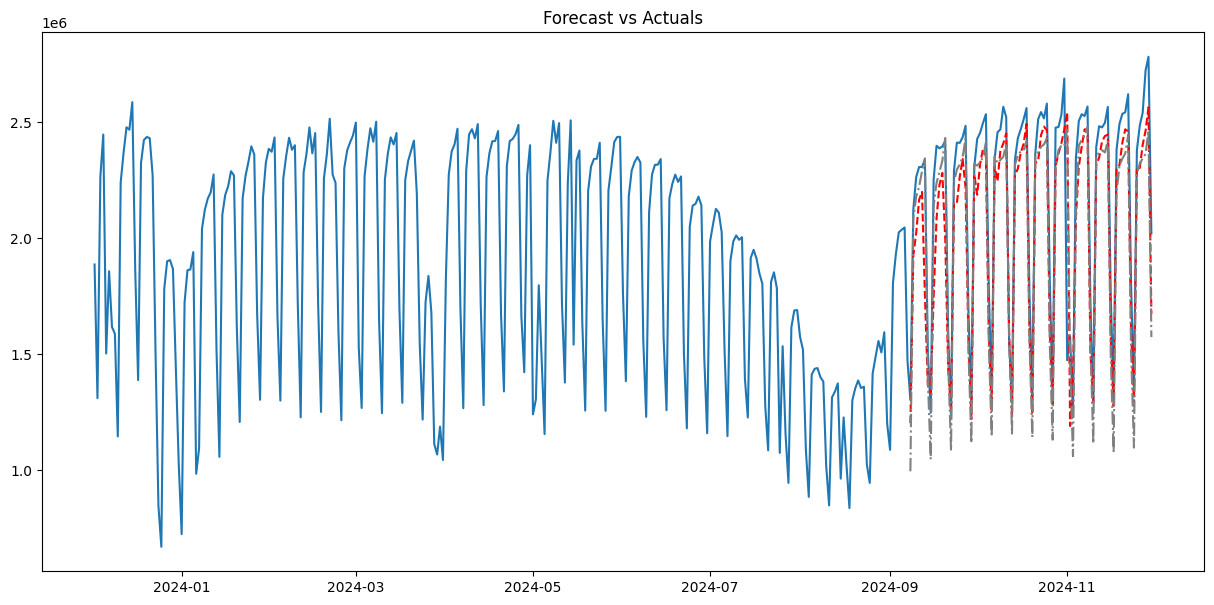

In [38]:
plt.figure(figsize=(15, 7))

plt.plot(df['Fecha'].iloc[-365:], df['Demanda'].iloc[-365:])
plt.plot(df['Fecha'].iloc[-84:], y_pred, color='red', linestyle='--')
plt.plot(df['Fecha'].iloc[-84:], y_pred2, color='gray', linestyle='-.')
#plt.plot(predictions_pmd, color='gray')
#plt.plot(test, color='blue')
plt.title('Forecast vs Actuals')
plt.show()

In [39]:
forecast_accuracy(y_pred2.T[0], df['Demanda'].iloc[-84:].to_numpy())

,Métrica,Valor
0,mape,0.080114
1,me,-128760.651786
2,mae,154073.660714
3,mpe,-0.063211
4,rmse,197524.336271
5,acf1,0.023492
6,corr,0.951635
7,minmax,0.076874


---
## 🏗️ Arquitectura: LSTM apiladas (Stacked LSTM)

Apilar varias capas LSTM permite aprender **representaciones jerárquicas** del tiempo:
- Las capas inferiores aprenden patrones de corto alcance (día a día)
- Las capas superiores aprenden patrones de largo alcance (semana a semana, estacionalidad)

**`return_sequences=True`**: cuando apilamos LSTMs, las capas intermedias deben devolver la secuencia completa (no solo el último estado) para que la capa siguiente la procese.

**`Dropout(0.2)`**: entre capas LSTM reduce el overfitting desactivando aleatoriamente el 20% de las neuronas durante el entrenamiento.

In [40]:
model = Sequential()
#Adding the first LSTM layer and some Dropout regularisation
model.add(LSTM(units = 50 , input_shape = (X_train.shape[1], 1)))
#model.add(LSTM(units = 50, return_sequences = True, input_shape = (X_train.shape[1], 1)))
model.add(Dropout(0.2))
# Adding a second LSTM layer and some Dropout regularisation
#model.add(LSTM(units = 50, return_sequences = True))
#model.add(Dropout(0.2))
# Adding a third LSTM layer and some Dropout regularisation
#model.add(LSTM(units = 50, return_sequences = True))
#model.add(Dropout(0.2))
# Adding a fourth LSTM layer and some Dropout regularisation
#model.add(LSTM(units = 50))
#model.add(Dropout(0.2))

model.add(Dense(units=32, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(units=16, activation='relu'))
model.add(Dropout(0.2))
# Adding the output layer
model.add(Dense(units = 1))

# Compiling the RNN

model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mse', 'mae', 'mape']  # Puedes añadir más métricas para análisis
)
# Fitting the RNN to the Training set
#model.fit(X_train, y_train, epochs = 70, batch_size = 32)

c:\Users\tomas\envs\dl\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### ⏹️ Early Stopping: detener el entrenamiento en el momento óptimo

Sin Early Stopping, el modelo podría sobreentrenarse: las métricas de training siguen mejorando pero las de validación empeoran (overfitting).

**Parámetros clave:**
- `monitor='val_loss'`: observamos la pérdida en el conjunto de validación
- `patience=20`: esperamos 20 épocas sin mejora antes de parar
- `restore_best_weights=True`: al terminar, recuperamos los pesos de la época con menor val_loss

> 💡 Esto nos permite poner `epochs=200` sin preocuparnos de sobreentrenar: el modelo parará automáticamente en el momento óptimo.

In [41]:
from tensorflow.keras.callbacks import EarlyStopping

# Crear el callback
early_stop = EarlyStopping(
    monitor='val_loss',     # Métrica que se observa
    patience=20,            # Nº de épocas sin mejora antes de parar
    restore_best_weights=True # Recupera los mejores pesos
)

# Entrenar el modelo con validación
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),  # Necesitas un conjunto de validación
    epochs=200,
    batch_size=32,
    callbacks=[early_stop]
)


Epoch 1/200
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0827 - mae: 0.2245 - mape: 80710.9922 - mse: 0.0827 - val_loss: 0.0312 - val_mae: 0.1623 - val_mape: 27.0477 - val_mse: 0.0312
Epoch 2/200
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0503 - mae: 0.1814 - mape: 61768.1328 - mse: 0.0503 - val_loss: 0.0341 - val_mae: 0.1705 - val_mape: 27.4414 - val_mse: 0.0341
Epoch 3/200
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0442 - mae: 0.1706 - mape: 59024.8320 - mse: 0.0442 - val_loss: 0.0310 - val_mae: 0.1633 - val_mape: 27.1753 - val_mse: 0.0310
Epoch 4/200
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0424 - mae: 0.1672 - mape: 72856.7734 - mse: 0.0424 - val_loss: 0.0309 - val_mae: 0.1635 - val_mape: 27.1717 - val_mse: 0.0309
Epoch 5/200
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0406 - mae: 0.1649 - mape: 74364.9844 - mse: 0.0406 - val_loss: 0.0285 - val_mae: 0.1553 - val_mape: 26.8683 - val_mse: 0.0285
Epoch 6/200
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0

In [42]:
y_pred3 = model.predict(X_test)
y_pred3 = sc.inverse_transform(y_pred3)

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/stepWARNING:tensorflow:6 out of the last 9 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000002C20B5CB920> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


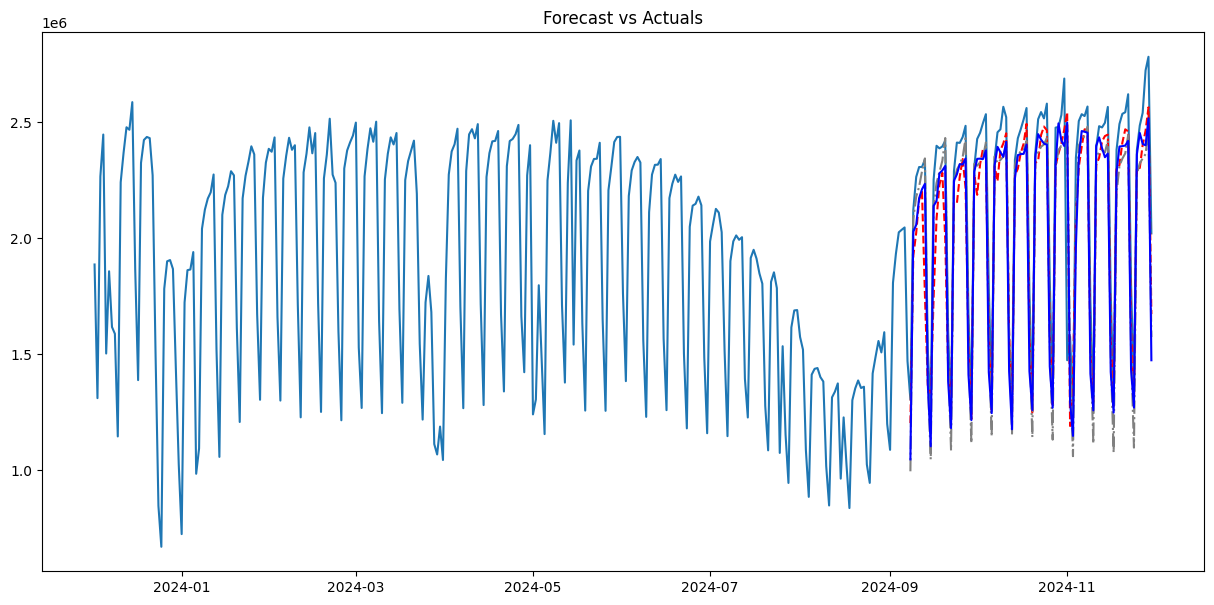

In [43]:
plt.figure(figsize=(15, 7))

plt.plot(df['Fecha'].iloc[-365:], df['Demanda'].iloc[-365:])
plt.plot(df['Fecha'].iloc[-84:], y_pred, color='red', linestyle='--')
plt.plot(df['Fecha'].iloc[-84:], y_pred2, color='gray', linestyle='-.')
plt.plot(df['Fecha'].iloc[-84:], y_pred3, color='blue')
#plt.plot(predictions_pmd, color='gray')
#plt.plot(test, color='blue')
plt.title('Forecast vs Actuals')
plt.show()

In [44]:
forecast_accuracy(y_pred3.T[0], df['Demanda'].iloc[-84:].to_numpy())

,Métrica,Valor
0,mape,0.078140
1,me,-130367.834821
2,mae,155297.025298
3,mpe,-0.061368
4,rmse,209021.911902
5,acf1,-0.115327
6,corr,0.940979
7,minmax,0.074742


---
## 🔄 Comparativa de modelos y siguientes pasos

### Resultados esperados

| Modelo | Arquitectura | Fortaleza |
|---|---|---|
| LSTM profunda | 4 capas LSTM | Captura dependencias largas |
| LSTM simple + Dense | 1 LSTM + capas Dense | Más ligera, menos overfitting |
| **GRU** | Similar a LSTM | Más rápida, menos parámetros |

### Ideas para mejorar el modelo

Los comentarios al final del notebook sugieren extensiones interesantes:

1. **Variables exógenas** (`dia_semana`, `mes`, `festivo`): la demanda del lunes no es la misma que la del viernes; el modelo sin estas variables tiene que inferirlo solo del patrón temporal
2. **Clima**: la lluvia reduce el uso de la bici pero puede aumentar el del metro
3. **Limpieza de outliers**: el COVID-19 introduce una caída anómala que puede distorsionar el aprendizaje de patrones normales
4. **Prophet / XGBoost con features temporales**: comparar con enfoques alternativos

#### Probamos con GRU

- usar dia de la semana, dia del mes, mes como input
- ver si hay alguna serie temporal que pueda influir en el numero de viajeros: prevision del tiempo?
- quitar observaciones pasadas que puedan meter ruido
- probar otros modelos 